In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'
NUTS2_ID = 'EL65'
NUTS1_COLNAME = 'NUTS1_ID'
NUTS2_COLNAME = 'NUTS2_ID'

In [4]:
shapefile_gdf = gpd.read_file(f"../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
shapefile_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'shapefile\'s CRS before conversion: {shapefile_gdf.crs}')
shapefile_gdf = shapefile_gdf.to_crs(epsg=4326)
print(f'shapefile\'s CRS after conversion: {shapefile_gdf.crs}')

shapefile's CRS before conversion: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
shapefile's CRS after conversion: EPSG:4326


In [7]:
shapefile_gdf[NUTS2_COLNAME].unique()

array(['EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52', 'EL53', 'EL54',
       'EL61', 'EL62', 'EL63', 'EL64', 'EL65'], dtype=object)

In [8]:
nuts3_gdf = shapefile_gdf.loc[shapefile_gdf[NUTS2_COLNAME] == f'{NUTS2_ID}'].copy()
nuts3_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
49,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL651,"Argolida, Arkadia","Αργολίδα, Αρκαδία",3.0,3,1,"MULTIPOLYGON (((22.26431 37.83916, 22.27648 37..."
50,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL652,Korinthia,Κορινθία,2.0,2,1,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38..."
51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1,"MULTIPOLYGON (((22.98080 37.04790, 22.99124 37..."


<Axes: >

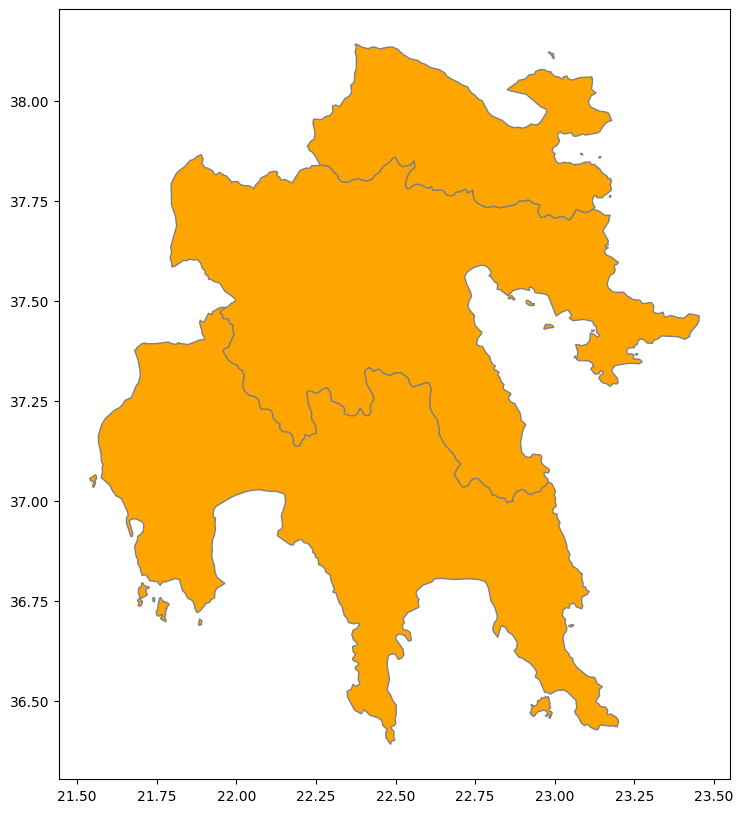

In [9]:
nuts3_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [10]:
nuts2_gdf = nuts3_gdf.dissolve(by = NUTS1_COLNAME, as_index = False)

<Axes: >

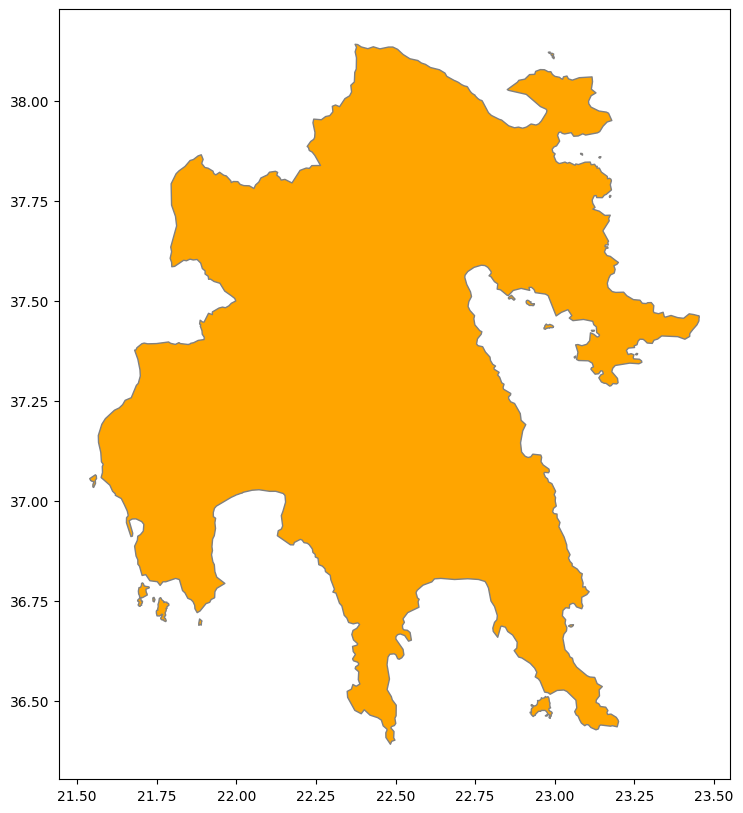

In [11]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [12]:
nuts2_gdf = nuts2_gdf[['NUTS2_ID', 'NUTS2_NAME', 'geometry']]
nuts2_gdf.reset_index(inplace=True, drop = True)

In [13]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal=NUTS2_COLNAME, dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [14]:
df_grid.shape

(3565, 5)

In [15]:
df_grid.head()

,geometry,centers,NUTS2_ID,x,y
0,"POLYGON ((21.60610 37.05665, 21.60610 37.07462...",POINT (21.594938712225826 37.06563193500806),EL65,21.59494,37.06563
1,"POLYGON ((21.60610 37.07462, 21.60610 37.09258...",POINT (21.594938712225826 37.083598626608264),EL65,21.59494,37.08360
2,"POLYGON ((21.60610 37.09258, 21.60610 37.11055...",POINT (21.594938712225826 37.101565318208486),EL65,21.59494,37.10157
3,"POLYGON ((21.60610 37.11055, 21.60610 37.12852...",POINT (21.594938712225826 37.119532009808694),EL65,21.59494,37.11953
4,"POLYGON ((21.60610 37.12852, 21.60610 37.14648...",POINT (21.594938712225826 37.13749870140891),EL65,21.59494,37.13750


<Axes: >

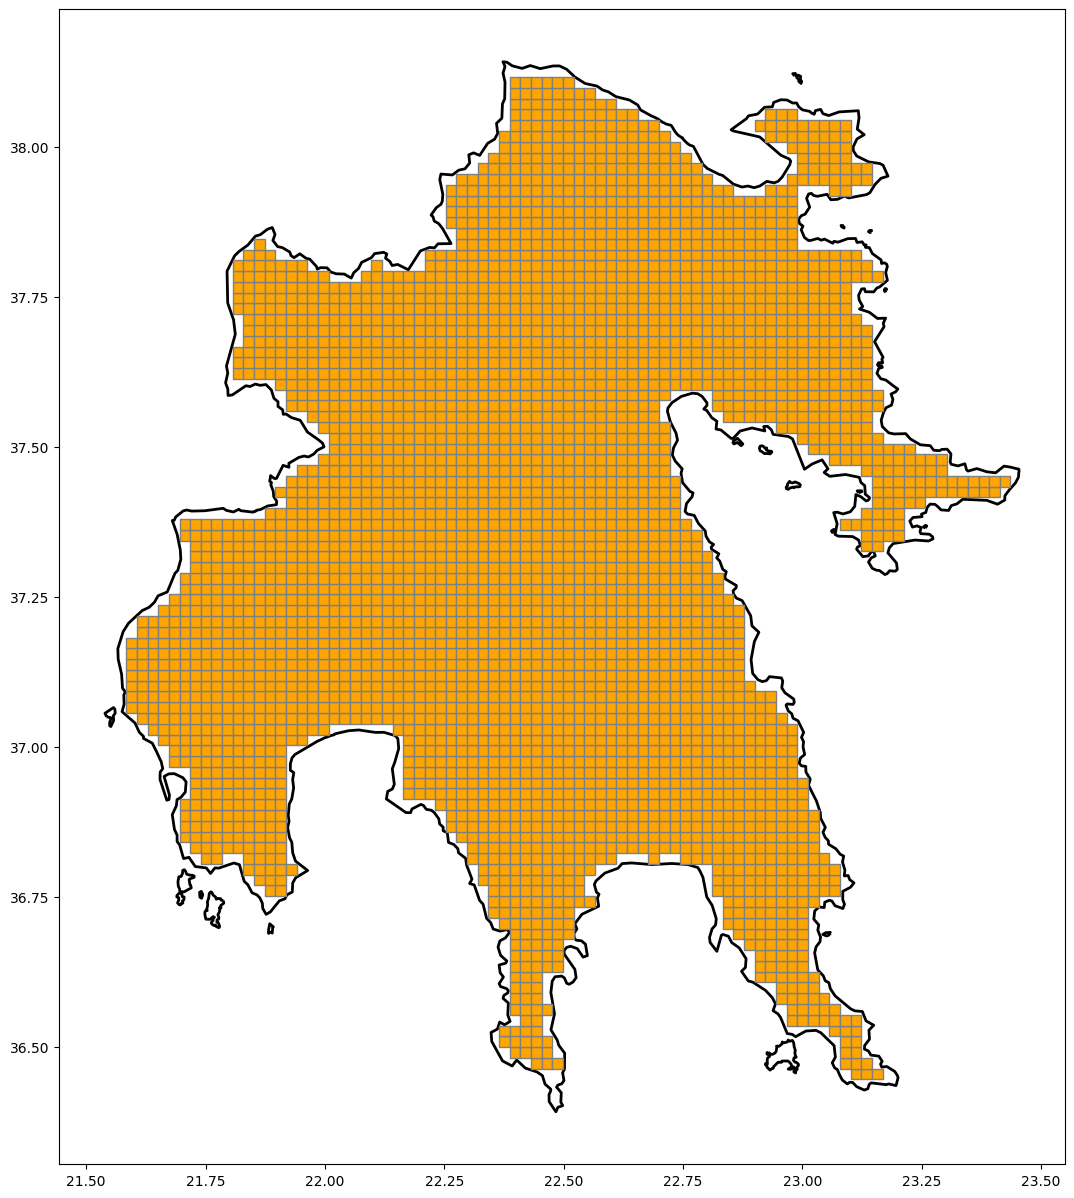

In [16]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [17]:
df_grid.set_geometry('centers', inplace=True)

In [18]:
gdf_merged = gpd.sjoin(df_grid, nuts3_gdf, how='left', op='within')
gdf_merged.set_geometry('geometry', inplace=True)

<Axes: >

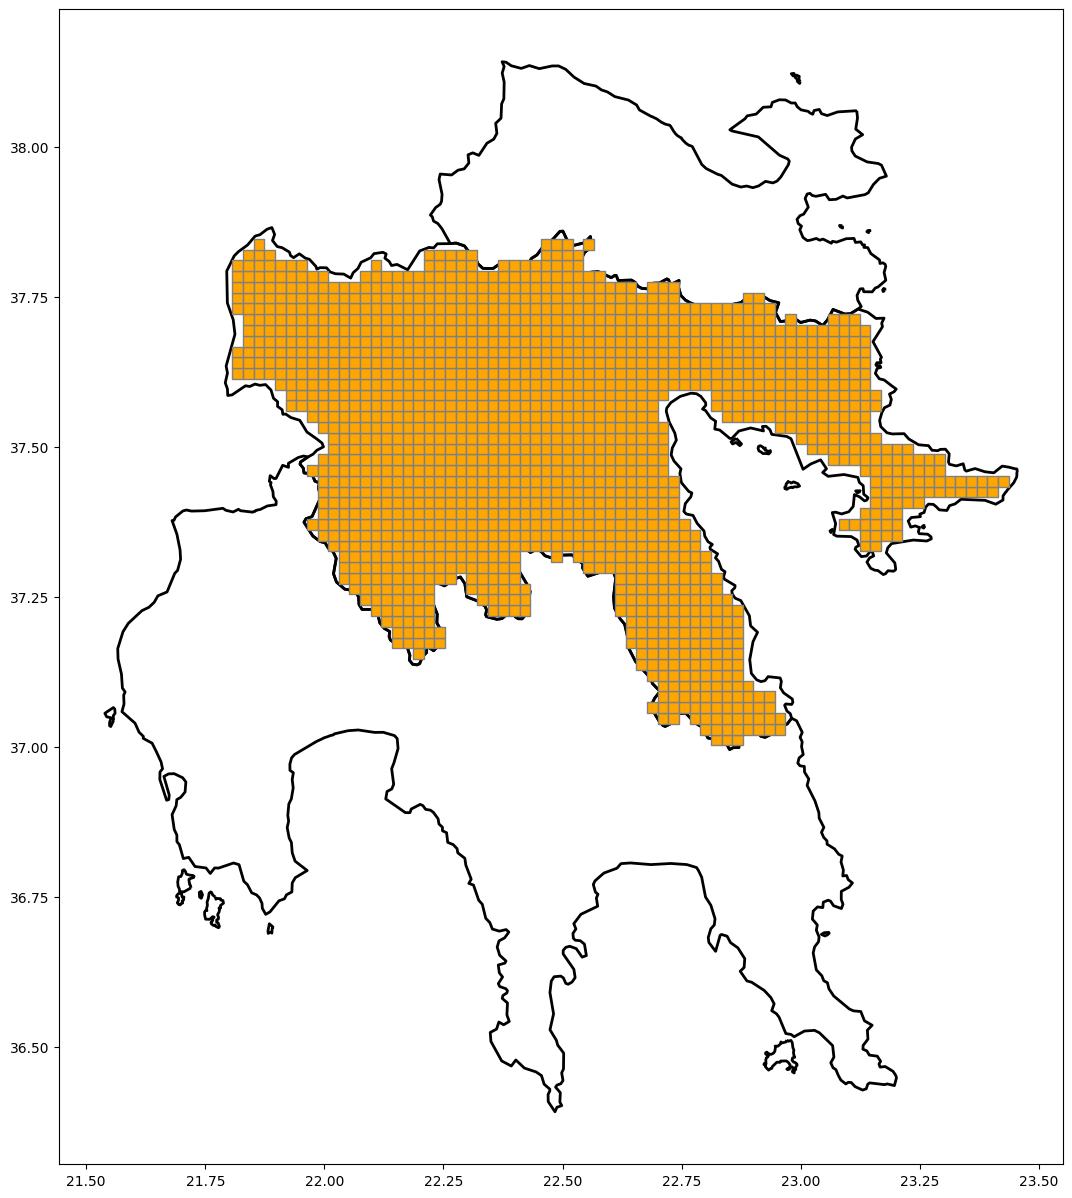

In [19]:
ax = nuts3_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
gdf_merged[gdf_merged['NUTS3_ID'] == 'EL651'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [20]:
gdf_merged.head()

,geometry,centers,NUTS2_ID_left,x,y,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID_right,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,"POLYGON ((21.60610 37.05665, 21.60610 37.07462...",POINT (21.59494 37.06563),EL65,21.59494,37.06563,51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1
1,"POLYGON ((21.60610 37.07462, 21.60610 37.09258...",POINT (21.59494 37.08360),EL65,21.59494,37.08360,51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1
2,"POLYGON ((21.60610 37.09258, 21.60610 37.11055...",POINT (21.59494 37.10157),EL65,21.59494,37.10157,51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1
3,"POLYGON ((21.60610 37.11055, 21.60610 37.12852...",POINT (21.59494 37.11953),EL65,21.59494,37.11953,51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1
4,"POLYGON ((21.60610 37.12852, 21.60610 37.14648...",POINT (21.59494 37.13750),EL65,21.59494,37.13750,51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1


In [21]:
final_grid = gdf_merged[['NUTS2_ID_left', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'geometry']]
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'NUTS2_ID_left': "NUTS2_ID"}, inplace=True)
final_grid.sort_values(by=['NUTS3_ID', 'x', 'y'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

In [22]:
final_grid['cell_code'] = final_grid['NUTS3_ID'] + pd.Series(final_grid.index + 1).apply(lambda x: f"{x:06d}")
process_greek(final_grid, 'NUTS3_NAME')
process_greek(final_grid, 'NUTS2_NAME')

In [23]:
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'cell_code', 'geometry']]

In [24]:
final_grid.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,geometry
0,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.81813,37.62260,EL651000001,"POLYGON ((21.82929 37.61362, 21.82929 37.63158..."
1,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.81813,37.64057,EL651000002,"POLYGON ((21.82929 37.63158, 21.82929 37.64955..."
2,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.81813,37.65853,EL651000003,"POLYGON ((21.82929 37.64955, 21.82929 37.66752..."
3,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.81813,37.73040,EL651000004,"POLYGON ((21.82929 37.72142, 21.82929 37.73938..."
4,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.81813,37.74837,EL651000005,"POLYGON ((21.82929 37.73938, 21.82929 37.75735..."


In [25]:
final_grid.drop(columns='geometry').to_csv(f'../data/GR_{NUTS2}_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/GR_{NUTS2}_Grid.shp', encoding = 'utf-8')